# Programación de algoritmos de Regresión Logística, clasificación binaria de eventos y evaluación de matrices de confusión.-Grupo A

# Tarea 1


Optimization terminated successfully.
         Current function value: 0.366379
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                  Falla   No. Observations:                  200
Model:                          Logit   Df Residuals:                      198
Method:                           MLE   Df Model:                            1
Date:                Tue, 21 Jul 2026   Pseudo R-squ.:                  0.4676
Time:                        17:06:51   Log-Likelihood:                -73.276
converged:                       True   LL-Null:                       -137.63
Covariance Type:            nonrobust   LLR p-value:                 7.874e-30
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -10.6766      1.372     -7.785      0.000     -13.365      -7.988
Temp_CPU       0.1604      0.

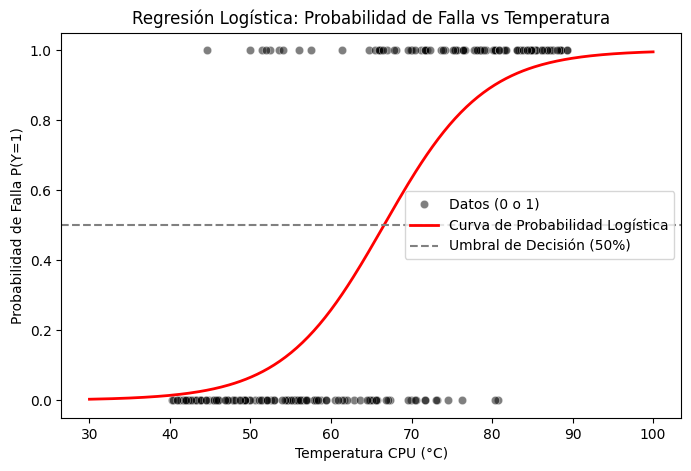

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
# 1. Generación de datos simulados (Clasificación Binaria)
np.random.seed(42)
n_muestras = 200

# Variable predictora: Temperatura CPU (entre 40 y 90 grados)

temp_cpu = np.random.uniform(40, 90, size=n_muestras)
# Generar variable binaria probabilística (A mayor temperatura, mayor probabilidad de falla)

z = -10 + 0.15 * temp_cpu # Ecuación lineal (Log-Odds)
probabilidad_falla = 1 / (1 + np.exp(-z)) # Transformación Sigmoide

# Variable respuesta binaria (0 = OK, 1 = Falla) basada en la probabilidad
falla_servidor = np.random.binomial(1, p=probabilidad_falla)
df_sim = pd.DataFrame({'Temp_CPU': temp_cpu, 'Falla': falla_servidor})
# 2. Ajuste del Modelo Logístico (Logit)
X_log = sm.add_constant(df_sim['Temp_CPU'])
Y_log = df_sim['Falla']

# Entrenamiento usando MLE (Maximum Likelihood Estimation)

modelo_logit = sm.Logit(Y_log, X_log).fit()
print(modelo_logit.summary())

# 3. Visualización de la Curva Sigmoide
x_rango = np.linspace(30, 100, 300)
x_rango_sm = sm.add_constant(x_rango)
y_pred_prob = modelo_logit.predict(x_rango_sm)
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Temp_CPU', y='Falla', data=df_sim, color='black', alpha=0.5,
label='Datos (0 o 1)')
plt.plot(x_rango, y_pred_prob, color='red', linewidth=2, label='Curva de Probabilidad Logística')
plt.axhline(0.5, color='gray', linestyle='--', label='Umbral de Decisión (50%)')
plt.title('Regresión Logística: Probabilidad de Falla vs Temperatura')
plt.xlabel('Temperatura CPU (°C)')
plt.ylabel('Probabilidad de Falla P(Y=1)')
plt.legend()
plt.show()

# Tarea 2


In [ ]:
import pandas as pd
import statsmodels.api as sm

# Uso del Proyecto Integrador
nombres_col = ["Fecha", "Tipo", "Emisor", "Cantidad", "Val_Nom", "Precio",
               "VNT", "Monto_Efectivo", "CO", "CD", "Bolsa"]

df = pd.read_csv("BVG_Acciones_export.csv", names=nombres_col, skiprows=1)

cols_interes = ['Monto_Efectivo', 'Cantidad', 'Precio']

for col in cols_interes:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna(subset=cols_interes)

# Binarización de la Variable Respuesta (Y)
# Definimos como 1 si el Monto_Efectivo supera el promedio, y 0 de lo contrario
promedio_monto = df['Monto_Efectivo'].mean()
df['Monto_Alto'] = (df['Monto_Efectivo'] > promedio_monto).astype(int)

print(f"Umbral de Binarización (Promedio): ${promedio_monto:,.2f} USD")
print(f"Distribución de Clases: \n{df['Monto_Alto'].value_counts(normalize=True)}")

# Selección de Predictoras (X) y Entrenamiento del Modelo Logístico
# X1 = Cantidad, X2 = Precio
X = df[['Cantidad', 'Precio']]
X = sm.add_constant(X)
Y = df['Monto_Alto']

modelo_logistico = sm.Logit(Y, X).fit()

print("\n--- RESUMEN DEL MODELO LOGÍSTICO ---")
print(modelo_logistico.summary())



Umbral de Binarización (Promedio): $13,171.56 USD
Distribución de Clases: 
Monto_Alto
0    0.834438
1    0.165562
Name: proportion, dtype: float64
Optimization terminated successfully.
         Current function value: 0.208096
         Iterations 10

--- RESUMEN DEL MODELO LOGÍSTICO ---
                           Logit Regression Results                           
Dep. Variable:             Monto_Alto   No. Observations:                29131
Model:                          Logit   Df Residuals:                    29128
Method:                           MLE   Df Model:                            2
Date:                Mon, 20 Jul 2026   Pseudo R-squ.:                  0.5363
Time:                        16:29:41   Log-Likelihood:                -6062.0
converged:                       True   LL-Null:                       -13073.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
-

### En una regresión logística binaria, el modelo estima el logaritmo de la razón de probabilidades (log-odds) de que ocurra el evento Y=1. Es decir, busca una relación lineal entre las variables predictoras y el log-odds de que una transacción sea de 'Alto Valor' (Y=1, cuando el Monto_Efectivo es superior al promedio de todas las transacciones) o de 'Bajo Valor' (Y=0, cuando es inferior o igual). Dado que los coeficientes de 'Cantidad' y 'Precio' son positivos, se infiere que un incremento en cualquiera de estas variables debería elevar la probabilidad de que la operación sea de 'Alto Valor'.
### Con respecto al valor P>|z|, tanto para 'Cantidad' como para 'Precio', el valor es muy cercano a 0. Esto indica que el volumen negociado y la valoración de la acción son factores determinantes para clasificar el `Monto_Efectivo` de las operaciones bursátiles en la región.

# Tarea 3


### De la Tarea  1

Optimization terminated successfully.
         Current function value: 0.366379
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                  Falla   No. Observations:                  200
Model:                          Logit   Df Residuals:                      198
Method:                           MLE   Df Model:                            1
Date:                Tue, 21 Jul 2026   Pseudo R-squ.:                  0.4676
Time:                        17:22:38   Log-Likelihood:                -73.276
converged:                       True   LL-Null:                       -137.63
Covariance Type:            nonrobust   LLR p-value:                 7.874e-30
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -10.6766      1.372     -7.785      0.000     -13.365      -7.988
Temp_CPU       0.1604      0.

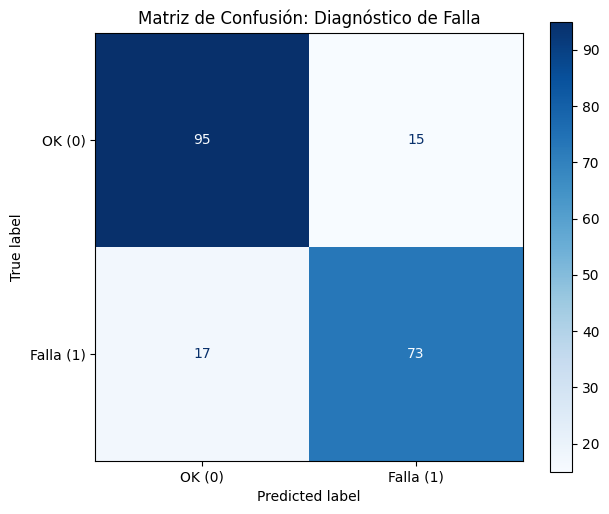

In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay

np.random.seed(42)
n_muestras = 200

# Predictora: Temperatura CPU (Variable continua)
temp_cpu = np.random.uniform(40, 90, size=n_muestras)

# Ecuación lineal (Log-Odds) y transformación Sigmoide
z = -10 + 0.15 * temp_cpu
probabilidad_falla = 1 / (1 + np.exp(-z))

# Respuesta binaria basada en la probabilidad (0 = OK, 1 = Falla)
falla_servidor = np.random.binomial(1, p=probabilidad_falla)
df_sim = pd.DataFrame({'Temp_CPU': temp_cpu, 'Falla': falla_servidor})

# AJUSTE DEL MODELO LOGÍSTICO (Logit)
X_log = sm.add_constant(df_sim['Temp_CPU'])
Y_log = df_sim['Falla']

# Entrenamiento usando MLE
modelo_logit = sm.Logit(Y_log, X_log).fit()
print(modelo_logit.summary())

# PREDICCIONES Y EVALUACIÓN MÉTRICA
probabilidades = modelo_logit.predict(X_log)

# Binarización de predicciones usando el umbral estándar de 0.50
predicciones_clase = (probabilidades >= 0.5).astype(int)

# Cálculo de la Matriz de Confusión y Exactitud
cm = confusion_matrix(Y_log, predicciones_clase)
exactitud = accuracy_score(Y_log, predicciones_clase)

print(f"\n--- Evaluación del Modelo Probabilístico ---")
print(f"Exactitud Global (Accuracy): {exactitud*100:.2f}%")

# VISUALIZACIÓN INTEGRAL
plt.figure(figsize=(12, 5))

# Subplot 2: Matriz de Confusión (Clasificación)
plt.subplot(1, 2, 2)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['OK (0)', 'Falla (1)'])
disp.plot(cmap='Blues', ax=plt.gca(), values_format='d')
plt.title('Matriz de Confusión: Diagnóstico de Falla')

plt.tight_layout()
plt.show()


### Del proyecto integrador

Umbral de Decisión: 0.50
Exactitud Global (Accuracy): 0.9208


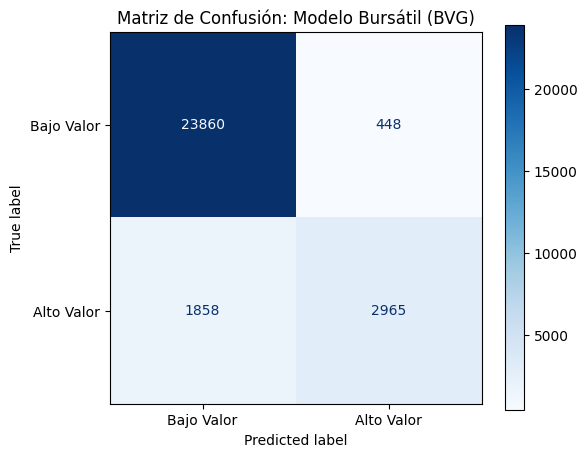

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay

nombres_col = ["Fecha", "Tipo", "Emisor", "Cantidad", "Val_Nom", "Precio",
               "VNT", "Monto_Efectivo", "CO", "CD", "Bolsa"]

df = pd.read_csv("BVG_Acciones_export.csv", names=nombres_col, skiprows=1)

df['Monto_Efectivo'] = pd.to_numeric(df['Monto_Efectivo'], errors='coerce')
df['Cantidad'] = pd.to_numeric(df['Cantidad'], errors='coerce')
df['Precio'] = pd.to_numeric(df['Precio'], errors='coerce')
df = df.dropna(subset=['Monto_Efectivo', 'Cantidad', 'Precio'])

promedio = df['Monto_Efectivo'].mean()
df['Monto_Alto'] = (df['Monto_Efectivo'] > promedio).astype(int)

X = df[['Cantidad', 'Precio']]
y = df['Monto_Alto']

# Inicialización y ajuste del modelo con scikit-learn
clf = LogisticRegression()
clf.fit(X, y)

# Extracción de predicciones basadas en el umbral de 0.50
y_pred = clf.predict(X)

# CÁLCULO DE MÉTRICAS
accuracy = accuracy_score(y, y_pred)
cm = confusion_matrix(y, y_pred)

print(f"Umbral de Decisión: 0.50")
print(f"Exactitud Global (Accuracy): {accuracy:.4f}")

# MATRIZ DE CONFUSIÓN
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Bajo Valor', 'Alto Valor'])
disp.plot(cmap='Blues', ax=ax)
plt.title("Matriz de Confusión: Modelo Bursátil (BVG)")
plt.show()

### En la matriz de confusión, el modelo clasifica correctamente 23860 transacciones como de "Bajo Valor". Además, 2965 transacciones son clasificadas correctamente como de "Alto Valor". Los otros dos recuadros representan los falsos positivos (transacciones de bajo valor clasificadas erróneamente como alto valor) y los falsos negativos (transacciones de alto valor clasificadas erróneamente como bajo valor).
### Un "accuracy" alto sugiere que las variables 'Precio' y 'Cantidad' son predictores sólidos para categorizar el valor de las operaciones.
### Sin embargo, con un "accuracy" alto y un dataset desbalanceado, podemos decir que el modelo podría estar sesgado hacia la predicción de la clase mayoritaria.

# Tarea 4


--- EVALUACIÓN CON UMBRAL 0.2 ---
Exactitud Global: 0.9235

Matriz de Confusión:
[[22906  1402]
 [  826  3997]]


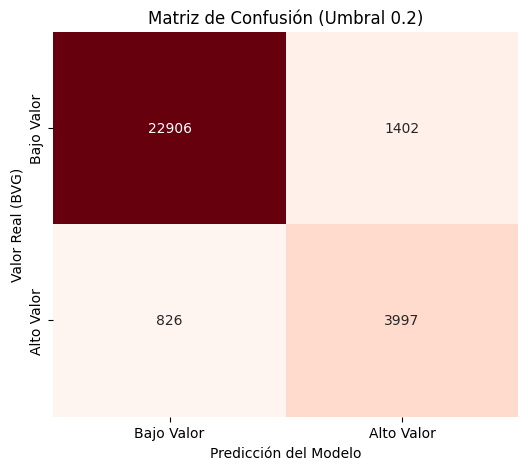

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

nombres_col = ["Fecha", "Tipo", "Emisor", "Cantidad", "Val_Nom", "Precio", "VNT", "Monto_Efectivo", "CO", "CD", "Bolsa"]

df = pd.read_csv("BVG_Acciones_export.csv", names=nombres_col, skiprows=1)

df[['Monto_Efectivo', 'Cantidad', 'Precio']] = df[['Monto_Efectivo', 'Cantidad', 'Precio']].apply(pd.to_numeric, errors='coerce')
df = df.dropna(subset=['Monto_Efectivo', 'Cantidad', 'Precio'])

df['Monto_Alto'] = (df['Monto_Efectivo'] > df['Monto_Efectivo'].mean()).astype(int)

X = df[['Cantidad', 'Precio']]
y = df['Monto_Alto']
clf = LogisticRegression().fit(X, y)

# Extraer probabilidades para la clase positiva (Alto Valor)
probs = clf.predict_proba(X)[:, 1]

# Umbral estricto de 0.20
umbral = 0.20
y_pred_02 = (probs >= umbral).astype(int)

# Matriz de Confusión
cm_02 = confusion_matrix(y, y_pred_02)
accuracy_02 = accuracy_score(y, y_pred_02)

print(f"--- EVALUACIÓN CON UMBRAL {umbral} ---")
print(f"Exactitud Global: {accuracy_02:.4f}")
print("\nMatriz de Confusión:")
print(cm_02)

# Visualización
plt.figure(figsize=(6, 5))
sns.heatmap(cm_02, annot=True, fmt='d', cmap='Reds', cbar=False)
plt.title(f"Matriz de Confusión (Umbral {umbral})")
plt.xlabel("Predicción del Modelo")
plt.ylabel("Valor Real (BVG)")
plt.xticks([0.5, 1.5], ['Bajo Valor', 'Alto Valor'])
plt.yticks([0.5, 1.5], ['Bajo Valor', 'Alto Valor'])
plt.show()

### Con el nuevo umbral (0.20), la sensibilidad y la precisión se ven directamente afectadas. Al reducir el umbral, la cantidad de falsos negativos disminuye significativamente, ya que el modelo ahora requiere menos evidencia para clasificar una transacción como de "Alto Valor". Por otro lado, los falsos positivos aumentan, lo que significa que más transacciones con una probabilidad intrínseca baja de ser de "Alto Valor" serán etiquetadas como tales.
### La elección del umbral debe basarse en la minimización del costo esperado. Si los costos asociados a un Falso Negativo son mayores que los de un Falso Positivo, se preferirá un modelo con mayor sensibilidad y menor precisión, para asegurar la detección de la información más relevante.